## Minería de flujos - Bloom Filter

Se detectan pares entidad-proveedor ya aparecidos con **Bloom Filter**

### Imports

In [1]:
import os, socket, sys, math, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
in_dir = proyecto / "04_Flujos" / "temp" / "a_dgim"
out_dir = proyecto / "04_Flujos" / "temp" / "b_bloom"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

- Figuras y tablas

In [3]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

- Spark

In [4]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("flujos-bloom")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [5]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga del flujo

- Se lee el flujo ordenado de `temp/a_dgim/flujo`

- Solo entran los procesos con `proveedor`

In [6]:
assert (in_dir / "flujo").exists(), "Corre a_dgim.ipynb (Run All) antes que este notebook."

flujo_pd = (spark.read.parquet(str(in_dir / "flujo"))
            .where("proveedor IS NOT NULL")
            .select("t", "fecha", "anio", "mes", "entidad", "proveedor", "postor_unico")
            .orderBy("t").toPandas())
pares = (flujo_pd["entidad"] + "|" + flujo_pd["proveedor"]).tolist()

L = len(pares)
n = len(set(pares))
print(f"Llegadas con proveedor (L): {L:,} | pares entidad-proveedor distintos (n): {n:,}")
print(f"Llegadas que repiten un par ya visto: {L - n:,} ({100 * (L - n) / L:.1f}%)")

Llegadas con proveedor (L): 184,248 | pares entidad-proveedor distintos (n): 123,871
Llegadas que repiten un par ya visto: 60,377 (32.8%)


### 2. Parámetros

In [7]:
P_OBJETIVO = 0.01
m = math.ceil(-n * math.log(P_OBJETIVO) / math.log(2) ** 2)
k = round(m / n * math.log(2))

print(f"m = {m:,} bits ({m / n:.1f} bits por par, {m / 8 / 1024:.0f} KB) | k = {k} funciones hash")

m = 1,187,311 bits (9.6 bits por par, 145 KB) | k = 7 funciones hash


- **`n`**: pares distintos esperados

- **`p = 1%`**: tasa de falsos positivos objetivo

- **`m = -n·ln p / (ln 2)²`**: tamaño mínimo del vector de bits para lograr `p` con `n` elementos

- **`k = (m/n)·ln 2`**: número de hashes que minimiza la FPR para ese `m/n`

- **Hashing**: un solo `blake2b` de 128 bits partido en `h1`, `h2`; el i-ésimo hash es `h1 + i·h2 mod m`

### 3. Bloom Filter

In [8]:
def hashes(clave):
    d = hashlib.blake2b(clave.encode("utf-8"), digest_size=16).digest()
    return int.from_bytes(d[:8], "little"), int.from_bytes(d[8:], "little") | 1

class BloomFilter:
    def __init__(self, m, k):
        self.m, self.k = m, k
        self.bits = bytearray((m + 7) // 8)

    def posiciones(self, h1, h2):
        return [(h1 + i * h2) % self.m for i in range(self.k)]

    def contiene(self, h1, h2):
        return all(self.bits[p >> 3] >> (p & 7) & 1 for p in self.posiciones(h1, h2))

    def visto_y_agregar(self, h1, h2):
        visto = True
        for p in self.posiciones(h1, h2):
            byte, bit = p >> 3, 1 << (p & 7)
            if not self.bits[byte] & bit:
                visto = False
                self.bits[byte] |= bit
        return visto

def fpr_teorica(m, k, n_insertados):
    return (1 - np.exp(-k * np.asarray(n_insertados) / m)) ** k

def bytes_set(s):
    return sys.getsizeof(s) + sum(sys.getsizeof(x) for x in s)

### 4. Simulación del flujo

Por cada llegada se valida si el par entidad-proveedor ya ha sido visto y luego se inserta

In [9]:
bf = BloomFilter(m, k)
visto_bloom = np.empty(L, dtype=bool)
t0 = time.perf_counter()
for i, par in enumerate(pares):
    visto_bloom[i] = bf.visto_y_agregar(*hashes(par))
seg_bloom = time.perf_counter() - t0

vistos = set()
visto_exacto = np.empty(L, dtype=bool)
t0 = time.perf_counter()
for i, par in enumerate(pares):
    visto_exacto[i] = par in vistos
    vistos.add(par)
seg_exacto = time.perf_counter() - t0

assert not (visto_exacto & ~visto_bloom).any(), "un Bloom Filter no puede tener falsos negativos"

nuevos = ~visto_exacto
fp = visto_bloom & nuevos
fpr_flujo = fp.sum() / nuevos.sum()
fpr_flujo_teo = fpr_teorica(m, k, np.arange(nuevos.sum())).mean()

SONDAS = 100_000
fpr_final = np.mean([bf.contiene(*hashes(f"__sonda__|{i}")) for i in range(SONDAS)])

mem_bloom, mem_exacta = len(bf.bits), bytes_set(vistos)
print(f"Falsos positivos: {fp.sum():,} de {nuevos.sum():,} pares nuevos")
print(f"FPR durante el flujo: {100 * fpr_flujo:.3f}% (teórica {100 * fpr_flujo_teo:.3f}%)")
print(f"FPR al final:         {100 * fpr_final:.3f}% (teórica {100 * fpr_teorica(m, k, n):.3f}%, objetivo {100 * P_OBJETIVO:.0f}%)")
print(f"Memoria: Bloom {mem_bloom / 1024:,.0f} KB | set exacto {mem_exacta / 1024**2:,.1f} MB ({mem_exacta / mem_bloom:.0f}x)")
print(f"Tiempo:  Bloom {1e6 * seg_bloom / L:.2f} µs/llegada | set exacto {1e6 * seg_exacto / L:.2f} µs/llegada")

Falsos positivos: 214 de 123,871 pares nuevos
FPR durante el flujo: 0.173% (teórica 0.166%)
FPR al final:         1.024% (teórica 1.004%, objetivo 1%)
Memoria: Bloom 145 KB | set exacto 19.1 MB (135x)
Tiempo:  Bloom 2.87 µs/llegada | set exacto 0.34 µs/llegada


#### a. Falsos positivos

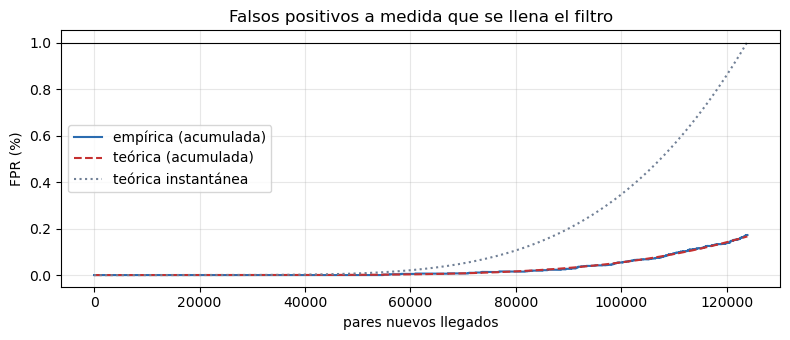

In [10]:
idx_nuevos = np.flatnonzero(nuevos)
fp_acum = np.cumsum(fp[idx_nuevos]) / np.arange(1, len(idx_nuevos) + 1)
fpr_instantanea = fpr_teorica(m, k, np.arange(len(idx_nuevos)))
fpr_teo_acum = np.cumsum(fpr_instantanea) / np.arange(1, len(idx_nuevos) + 1)

plt.figure(figsize=(8, 3.5))
plt.plot(100 * fp_acum, color="#2b6cb0", label="empírica (acumulada)")
plt.plot(100 * fpr_teo_acum, color="#c53030", linestyle="--", label="teórica (acumulada)")
plt.plot(100 * fpr_instantanea, color="#718096", linestyle=":", label="teórica instantánea")
plt.axhline(100 * P_OBJETIVO, color="black", linewidth=.8)
plt.xlabel("pares nuevos llegados"); plt.ylabel("FPR (%)"); plt.legend()
plt.title("Falsos positivos a medida que se llena el filtro")
mostrar_fig("fpr_evolucion")

paso = max(1, len(idx_nuevos) // 500)
fpr_evolucion = pd.DataFrame({"pares_nuevos": np.arange(1, len(idx_nuevos) + 1)[::paso],
                              "fpr_empirica": fp_acum[::paso], "fpr_teorica": fpr_teo_acum[::paso],
                              "fpr_instantanea": fpr_instantanea[::paso]})

- 214 falsos positivos de 123,871 pares nuevos

- FPR durante el flujo de 0.173% (teórica 0.166%)

- Al final, con los 123,871 pares insertados: 1.024% vs 1.004% teórica

- El FPR durante el flujo es mucho menor que al final porque el filtro se va llenando

#### b. Reincidencia

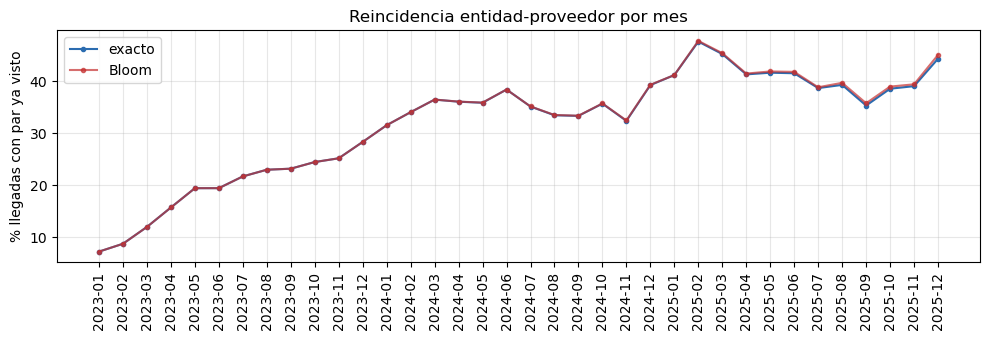

In [11]:
flujo_pd["reincide_exacto"] = visto_exacto
flujo_pd["reincide_bloom"] = visto_bloom

reincidencia_mes = (flujo_pd.groupby(["anio", "mes"])
                    .agg(llegadas=("t", "size"),
                         pct_reincide_exacto=("reincide_exacto", "mean"),
                         pct_reincide_bloom=("reincide_bloom", "mean")).reset_index())
reincidencia_mes[["pct_reincide_exacto", "pct_reincide_bloom"]] *= 100

etiquetas = reincidencia_mes["anio"].astype(str) + "-" + reincidencia_mes["mes"].astype(str).str.zfill(2)
plt.figure(figsize=(10, 3.5))
plt.plot(etiquetas, reincidencia_mes["pct_reincide_exacto"], marker="o", ms=3, color="#2b6cb0", label="exacto")
plt.plot(etiquetas, reincidencia_mes["pct_reincide_bloom"], marker="o", ms=3, color="#c53030", alpha=.7, label="Bloom")
plt.xticks(rotation=90); plt.ylabel("% llegadas con par ya visto"); plt.legend()
plt.title("Reincidencia entidad-proveedor por mes")
mostrar_fig("reincidencia_mes")

In [12]:
postor_reincidencia = (flujo_pd.dropna(subset=["postor_unico"])
                       .groupby("reincide_exacto")["postor_unico"].agg(["size", "mean"])
                       .rename(index={False: "primera vez", True: "reincidente"}, columns={"size": "llegadas", "mean": "pct_postor_unico"}))
postor_reincidencia["pct_postor_unico"] = (100 * postor_reincidencia["pct_postor_unico"]).round(1)
postor_reincidencia = postor_reincidencia.rename_axis("par").reset_index()
postor_reincidencia

,par,llegadas,pct_postor_unico
0,primera vez,123860,11.9
1,reincidente,60369,16.3


- El 32.8% de las llegadas (60,377 de 184,248) repite un par entidad-proveedor ya visto

- La reincidencia sube de 19.0% (2023) a 35.2% (2024) y 41.2% (2025)

- El filtro nunca olvida, entonces con más historia hay más pares "ya vistos"

### 5. Precisión, memoria y tiempo

Grilla: bits por par (`m/n`) × `k` y los hashes `h1` y `h2`

In [13]:
hs = [hashes(par) for par in pares]
sondas = [hashes(f"__sonda__|{i}") for i in range(20_000)]

filas, vistos_config = [], {}
for bpe in [2, 4, 8, round(m / n, 1), 16]:
    m_ = math.ceil(bpe * n)
    for k_ in [1, 2, 3, 5, 7, 10]:
        bf_ = BloomFilter(m_, k_)
        vb = np.empty(L, dtype=bool)
        t0 = time.perf_counter()
        for i, (h1, h2) in enumerate(hs):
            vb[i] = bf_.visto_y_agregar(h1, h2)
        seg_ = time.perf_counter() - t0
        vistos_config[(bpe, k_)] = vb
        filas.append({"bits_por_par": bpe, "k": k_, "m": m_, "memoria_kb": m_ / 8 / 1024,
                      "fpr_flujo": (vb & nuevos).sum() / nuevos.sum(),
                      "fpr_final": np.mean([bf_.contiene(h1, h2) for h1, h2 in sondas]),
                      "fpr_final_teorica": float(fpr_teorica(m_, k_, n)),
                      "us_por_llegada": 1e6 * seg_ / L})

tradeoff = pd.DataFrame(filas)
tradeoff.round(4)

,bits_por_par,k,m,memoria_kb,fpr_flujo,fpr_final,fpr_final_teorica,us_por_llegada
0,2.0,1,247742,30.2419,0.2128,0.3936,0.3935,0.7352
1,2.0,2,247742,30.2419,0.1683,0.3956,0.3996,0.9103
2,2.0,3,247742,30.2419,0.1780,0.4646,0.4689,1.1790
3,2.0,5,247742,30.2419,0.2380,0.6473,0.6516,1.4251
4,2.0,7,247742,30.2419,0.3165,0.8046,0.8068,1.7054
5,2.0,10,247742,30.2419,0.4276,0.9314,0.9346,2.1418
6,4.0,1,495484,60.4839,0.1163,0.2203,0.2212,0.7403
7,4.0,2,495484,60.4839,0.0584,0.1509,0.1548,0.9377
8,4.0,3,495484,60.4839,0.0454,0.1448,0.1469,1.1110
9,4.0,5,495484,60.4839,0.0472,0.1866,0.1849,1.4623


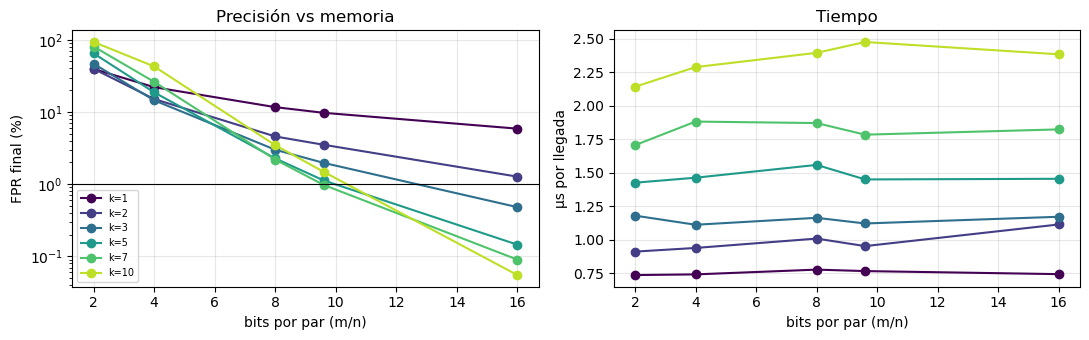

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
colores = plt.cm.viridis(np.linspace(0, .9, tradeoff["k"].nunique()))
for (k_, g), c in zip(tradeoff.groupby("k"), colores):
    ax[0].plot(g["bits_por_par"], 100 * g["fpr_final"], marker="o", color=c, label=f"k={k_}")
    ax[1].plot(g["bits_por_par"], g["us_por_llegada"], marker="o", color=c, label=f"k={k_}")
ax[0].axhline(100 * P_OBJETIVO, color="black", linewidth=.8)
ax[0].set_yscale("log"); ax[0].set_xlabel("bits por par (m/n)"); ax[0].set_ylabel("FPR final (%)")
ax[0].set_title("Precisión vs memoria"); ax[0].legend(fontsize=7)
ax[1].set_xlabel("bits por par (m/n)"); ax[1].set_ylabel("µs por llegada"); ax[1].set_title("Tiempo")
mostrar_fig("tradeoff_bloom")

- Más bits por par, menos falsos positivos: 2 bits → 39.4%, 8 → 2.2%, 9.6 → 1.0%, 16 → 0.06%

- Cada `m/n` tiene un `k` óptimo; con más hashes se llena el filtro

- El tiempo crece con `k` no con `m`

- 145 KB vs 18.1 MB del `set` exacto (128x menos)

### 6. Variación de parámetros

Se mide cómo cambian los resultados según `m/n` y `k`

In [15]:
anio = flujo_pd["anio"].to_numpy()
pu = flujo_pd["postor_unico"].to_numpy(dtype=float)

def resultado(visto):
    r = {"reincidencia": 100 * visto.mean(),
         **{f"reincidencia_{a}": 100 * visto[anio == a].mean() for a in sorted(set(anio))},
         "pu_reincidente": 100 * np.nanmean(pu[visto]), "pu_primera_vez": 100 * np.nanmean(pu[~visto])}
    r["brecha_pu"] = r["pu_reincidente"] - r["pu_primera_vez"]
    return r

real = resultado(visto_exacto)
variacion = pd.DataFrame([{"bits_por_par": bpe, "k": k_, **resultado(vb)} for (bpe, k_), vb in vistos_config.items()])
variacion["reincidencia_exacta"], variacion["brecha_pu_exacta"] = real["reincidencia"], real["brecha_pu"]

print(f"Exacto: reincidencia {real['reincidencia']:.1f}% | postor único reincidente {real['pu_reincidente']:.1f}% "
      f"vs primera vez {real['pu_primera_vez']:.1f}% (brecha {real['brecha_pu']:+.1f} pp)")
variacion.round(2)

Exacto: reincidencia 32.8% | postor único reincidente 16.3% vs primera vez 11.9% (brecha +4.4 pp)


,bits_por_par,k,reincidencia,reincidencia_2023,reincidencia_2024,reincidencia_2025,pu_reincidente,pu_primera_vez,brecha_pu,reincidencia_exacta,brecha_pu_exacta
0,2.0,1,47.08,28.35,50.91,61.35,14.63,12.26,2.37,32.77,4.4
1,2.0,2,44.08,24.10,47.01,60.50,14.89,12.19,2.70,32.77,4.4
2,2.0,3,44.73,23.17,46.93,63.44,14.77,12.26,2.51,32.77,4.4
3,2.0,5,48.77,22.90,50.40,72.25,14.47,12.34,2.13,32.77,4.4
4,2.0,7,54.05,23.25,56.32,81.66,14.09,12.55,1.54,32.77,4.4
5,2.0,10,61.52,24.42,67.20,91.75,13.61,13.01,0.60,32.77,4.4
6,4.0,1,40.59,24.96,43.96,52.33,15.28,12.08,3.20,32.77,4.4
7,4.0,2,36.70,22.08,39.35,48.19,15.78,11.99,3.79,32.77,4.4
8,4.0,3,35.82,21.58,38.19,47.25,15.93,11.96,3.97,32.77,4.4
9,4.0,5,35.94,21.39,37.66,48.33,15.84,12.00,3.83,32.77,4.4


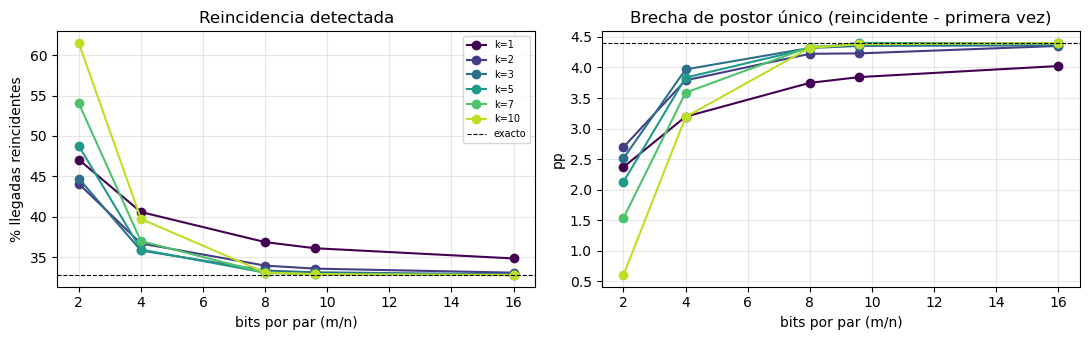

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
colores = plt.cm.viridis(np.linspace(0, .9, variacion["k"].nunique()))
for (k_, g), c in zip(variacion.groupby("k"), colores):
    ax[0].plot(g["bits_por_par"], g["reincidencia"], marker="o", color=c, label=f"k={k_}")
    ax[1].plot(g["bits_por_par"], g["brecha_pu"], marker="o", color=c, label=f"k={k_}")
ax[0].axhline(real["reincidencia"], color="black", linestyle="--", linewidth=.8, label="exacto")
ax[1].axhline(real["brecha_pu"], color="black", linestyle="--", linewidth=.8, label="exacto")
ax[0].set_xlabel("bits por par (m/n)"); ax[0].set_ylabel("% llegadas reincidentes"); ax[0].set_title("Reincidencia detectada")
ax[1].set_xlabel("bits por par (m/n)"); ax[1].set_ylabel("pp"); ax[1].set_title("Brecha de postor único (reincidente - primera vez)")
ax[0].legend(fontsize=7)
mostrar_fig("variacion_bloom")

- Con 2 bits por par, Bloom infla la reincidencia a 44-62%, con la real en 32.8%

- Desde 8 bits por par se estabiliza en ~33%

- La configuración elegida (9.6 bits, k=7) da 32.9%

### 7. Escritura de resultados

Tablas en `temp/b_bloom/tablas/` y `temp/b_bloom/web/`

In [17]:
resumen = pd.DataFrame([{
    "estructura": "Bloom Filter", "tarea": "reincidencia entidad-proveedor", "parametros": f"m={m}, k={k}",
    "metrica_error": "tasa de falsos positivos (final)", "error": float(fpr_final),
    "memoria_bytes": float(mem_bloom), "memoria_exacta_bytes": float(mem_exacta),
    "us_por_elemento": 1e6 * seg_bloom / L, "us_por_elemento_exacto": 1e6 * seg_exacto / L}])

tablas = {"fpr_evolucion": fpr_evolucion, "reincidencia_mes": reincidencia_mes,
          "postor_reincidencia": postor_reincidencia, "tradeoff": tradeoff, "variacion": variacion, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/b_bloom/: {', '.join(escritos)}")

Escrito en temp/b_bloom/: fpr_evolucion, reincidencia_mes, postor_reincidencia, tradeoff, variacion, resumen


#### a. Verificación

In [18]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 6 tablas (parquet + json) | 4 figuras: fpr_evolucion, reincidencia_mes, tradeoff_bloom, variacion_bloom


---
### 8. Cerrar sesión

In [19]:
spark.stop()